# Housing Price Prediction using Linear Regression

## Assignment 2

### Objective:
- Perform data preprocessing
- Perform Exploratory Data Analysis (EDA)
- Train Linear Regression Model
- Predict Housing Prices
- Evaluate model performance

In [20]:
# Import necessary libraries

import pandas as pd
import numpy as np

# Data Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Model Evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


## 1. Loading Dataset

In this step, we will load the Housing dataset and view the first few rows.

In [21]:
# Load Housing dataset

df = pd.read_csv("Housing.csv")

# Display first 5 rows

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


 2. Understanding Dataset

Checking dataset structure, columns, and statistical information.

In [22]:
# Check number of rows and columns

df.shape

(545, 13)

In [23]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [24]:
# Statistical description of numerical columns

df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## 3. Data Cleaning

Checking missing values present in the dataset.

In [25]:
# Check missing values

df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## 4. Checking Dataset Columns

In this step, we will check all available columns in the dataset.

In [26]:
# Display all column names

df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

## 5. Exploratory Data Analysis (EDA)

In this section, we will analyze the dataset using visualizations.

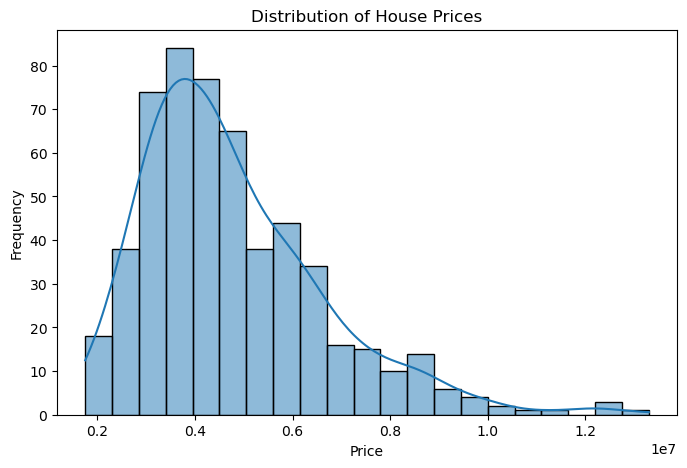

In [27]:
# Plot distribution of house prices

plt.figure(figsize=(8,5))

sns.histplot(df['price'], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

## 6. Correlation Analysis

Checking the relationship between numerical features and price.

In [28]:
# Select numerical columns

numeric_df = df.select_dtypes(include=['int64','float64'])

# Display correlation

numeric_df.corr()

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


## 7. Correlation Heatmap

Visualizing correlations between numerical features.

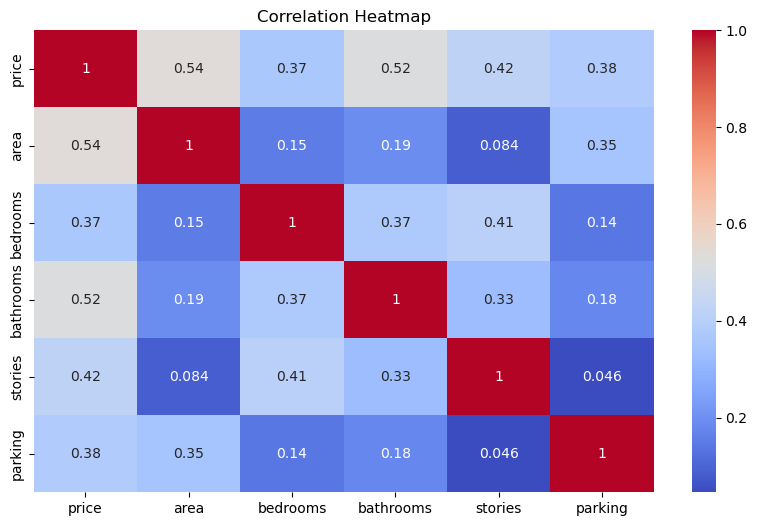

In [29]:
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## 8. Data Preprocessing

Converting categorical variables into numerical values using encoding.

In [30]:
# Convert categorical columns into numerical values

df_encoded = pd.get_dummies(df, drop_first=True)

# Display first 5 rows

df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


 ## 9. Checking Encoded Dataset Columns

After encoding, we check all available features.

In [31]:
# Display columns after encoding

df_encoded.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')

## 10. Feature Selection

Separating independent variables (features) and dependent variable (price).

In [13]:
# Independent variables

X = df_encoded.drop('price', axis=1)


# Target variable

y = df_encoded['price']


print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (545, 13)
Target Shape: (545,)


## 11. Splitting Dataset

Dividing data into training and testing sets.

In [14]:
# Split dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (436, 13)
Testing Data: (109, 13)


## 12. Building Linear Regression Model

In this step, we will train the Linear Regression model using training data.

In [15]:
# Create Linear Regression model

model = LinearRegression()

# Train the model

model.fit(X_train, y_train)

print("Model Training Completed Successfully")

Model Training Completed Successfully


## 13. Making Predictions

Using the trained model to predict house prices on test data.

In [16]:
# Predict prices

y_pred = model.predict(X_test)

# Display first 5 predictions

y_pred[:5]

array([5164653.90033967, 7224722.29802167, 3109863.24240338,
       4612075.32722559, 3294646.25725955])

## 14. Actual vs Predicted Prices

Comparing actual prices with model predictions.

In [17]:
# Create comparison dataframe

comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

# Display first 10 values

comparison.head(10)

,Actual Price,Predicted Price
316,4060000,5.164654e+06
77,6650000,7.224722e+06
360,3710000,3.109863e+06
90,6440000,4.612075e+06
493,2800000,3.294646e+06
209,4900000,3.532275e+06
176,5250000,5.611775e+06
249,4543000,6.368146e+06
516,2450000,2.722857e+06
426,3353000,2.629406e+06


## 15. Model Evaluation

Evaluating the model performance using MAE, MSE, RMSE and R² Score.

In [18]:
# Calculate evaluation metrics

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)


print("Mean Absolute Error (MAE):", mae)

print("Mean Squared Error (MSE):", mse)

print("Root Mean Squared Error (RMSE):", rmse)

print("R2 Score:", r2)

Mean Absolute Error (MAE): 970043.4039201635
Mean Squared Error (MSE): 1754318687330.663
Root Mean Squared Error (RMSE): 1324506.9600914384
R2 Score: 0.6529242642153186


## 16. Visualization of Actual and Predicted Prices

Visualizing the difference between actual and predicted values.

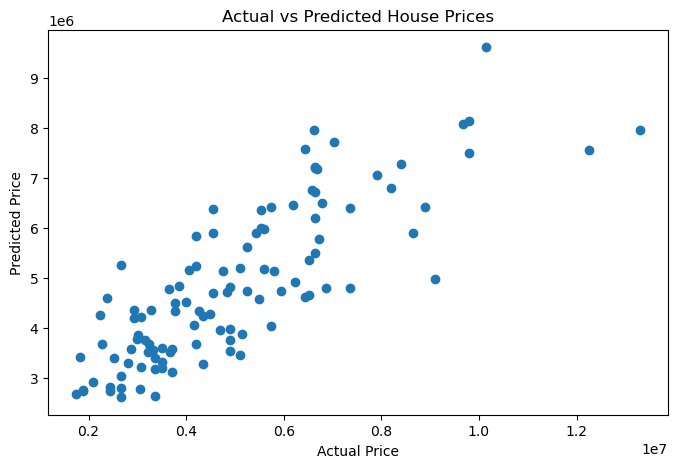

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()